## Домашнє завдання


Ну що, ви вже налаштувалися на виконання нового завдання?

Сьогодні використаємо градієнтний спуск для побудови поліноміальної регресії. Ви згенеруєте набір даних для проведення обчислювальних експериментів та програмно реалізуєте декілька варіантів метода градієнтного спуска: SGD, RMSProp, Adam, Nadam.
Під час обчислювальних експериментів ви зможете порівняти швидкість роботи та необхідну кількість ітерацій для кожного з варіантів.

Це допоможе закрiпити наступні навички:  

- градієнт, використання методу градієнтного спуску
- оптимізація в машинному навчанні.

## Завдання (крок за кроком)

Для цієї задачі необхідно буде згенерувати дані. Для 100 випадкових ознак $x_1$, $x_2$ потрібно обчислити $y$ як поліном 2-го степеня. Наприклад,

$4x_1^2 + 5x_2^2 - 2x_1x_2 + 3x_1 - 6x_2$.

В результаті, ми отримаємо масив ознак розмірністю (100,2) та масив цільової змінної розмірністю (100,).

 Для виконання завдання необхідно виконати такі кроки:

**1. Згенеруйте дані:**
*   Використовуйте функцію np.random.rand() для генерації 100 випадкових значень ознак x1, x2.
*   Реалізуйте функцію polynomial(x1, x2) для обчислення цільової змінної y за вказаним поліномом.


**2. Згенеруйте додаткові ознаки для кожного степеня за допомогою функції PolynomialFeatures бібліотеки sklearn.**

**3. Реалізуйте функції для методів градієнтного спуску:**

*   Реалізувати функцію polynomial_regression_gradient_descent() для обчислення коефіцієнтів поліноміальної регресії методом градієнтного спуску.

*   Реалізувати функцію polynomial_regression_SGD() варіанта SGD метода градієнтного спуску.

*   Реалізувати функцію polynomial_regression_rmsprop() варіанта RMSProp метода градієнтного спуску.

*   Реалізувати функцію polynomial_regression_adam() варіанта Adam метода градієнтного спуску.

*   Реалізувати функцію polynomial_regression_nadam() варіанта Nadam метода градієнтного спуску.

**4. Обчисліть час роботи реалізованих функцій за допомогою функції %timeit.**

**5. Підбереріть оптимальну кількість ітерацій кожного з варіантів метода.**

**6. Зробіть висновок про обчислювальну ефективність розглянутих варіантів метода градієнтного спуску.**


## Пiдказки

Для виконання завдання використовуй функції numpy, та алгоритми з конспекту до цієї теми.

##Формат здачі

1. Завантажте блокнот Google Colab у форматі IPYNB на свій комп’ютер та прикріпіть його у LMS.

2. Прикріпіть посилання на ваш Colab у LMS, відправте на перевірку.

## Критерії прийому

- Усі вказані етапи виконані та проведені обчислювальні експерименти з різними ступенями стискання.
- До Colab додані висновки.

## Формат оцінювання
- Залік/Незалік

##Приклад

Gradient Descent Algorithm

https://medium.com/data-science/gradient-descent-algorithm-a-deep-dive-cf04e8115f21

A Visual Explanation of Gradient Descent Methods (Momentum, AdaGrad, RMSProp, Adam)

https://medium.com/data-science/a-visual-explanation-of-gradient-descent-methods-momentum-adagrad-rmsprop-adam-f898b102325c

An overview of gradient descent optimization algorithms

https://www.ruder.io/optimizing-gradient-descent/

##Градієнти

Градієнт у задачі регресії — це вектор похідних функції втрат (зазвичай середньоквадратичної помилки, MSE) по параметрах моделі. Мета — змінювати параметри в напрямку протилежному до градієнта, щоби зменшити помилку.

Розглянемо стандартну функцію втрат:

$$
L(\theta) = \frac{1}{2m} \sum_{i=1}^{m} \left( \hat{y}^{(i)} - y^{(i)} \right)^2 = \frac{1}{2m} \sum_{i=1}^{m} \left( X^{(i)} \theta - y^{(i)} \right)^2
$$

### 1. **Gradient Descent (GD)** — **"пакетний градієнт"**

**Оновлення параметрів**:

$$
\theta := \theta - \eta \cdot \nabla_\theta L
$$

**Градієнт** (усереднений по всіх прикладах):

$$
\nabla_\theta L = \frac{1}{m} X^T (X \theta - y)
$$

Це похідна функції втрат за всіма параметрами — розрахунок точний, але повільний для великих наборів даних.

---

### 2. **Stochastic Gradient Descent (SGD)** — **"градієнт на одному прикладі"**

**Оновлення параметрів**:

$$
\theta := \theta - \eta \cdot \nabla_\theta L^{(i)}
$$

**Градієнт** для одного випадкового прикладу:

$$
\nabla_\theta L^{(i)} = x^{(i)} \cdot (x^{(i)} \theta - y^{(i)})
$$

Це "шумний" градієнт — менш точний, але дозволяє робити частіші оновлення та швидше збігається (особливо на початку).

---

### 3. **RMSProp** — **адаптивна швидкість для кожного параметра**

Як у SGD, але з пам’яттю про попередні градієнти:

$$
\text{cache}_t = \rho \cdot \text{cache}_{t-1} + (1 - \rho) \cdot g_t^2
$$

$$
\theta := \theta - \frac{\eta}{\sqrt{\text{cache}_t} + \varepsilon} \cdot g_t
$$

Де $g_t$ — поточний градієнт. Ідея — зменшити крок, коли градієнт довгий у певному напрямку.

---

### 4. **Adam (Adaptive Moment Estimation)**

Поєднує:

* **перший момент** (середнє значення градієнтів):

  $$
  m_t = \beta_1 m_{t-1} + (1 - \beta_1) g_t
  $$
* **другий момент** (середнє квадратів градієнтів):

  $$
  v_t = \beta_2 v_{t-1} + (1 - \beta_2) g_t^2
  $$

З поправкою на початок:

$$
\hat{m}_t = \frac{m_t}{1 - \beta_1^t}, \quad \hat{v}_t = \frac{v_t}{1 - \beta_2^t}
$$

Оновлення параметрів:

$$
\theta := \theta - \frac{\eta}{\sqrt{\hat{v}_t} + \varepsilon} \cdot \hat{m}_t
$$

**Перевага**: поєднує стабільність RMSProp і згладжування

---

### 5. **Nadam (Nesterov + Adam)**

Це Adam, але з прогнозуванням майбутнього кроку (як у **Nesterov momentum**):

$$
\theta := \theta - \frac{\eta}{\sqrt{\hat{v}_t} + \varepsilon} \cdot \left( \beta_1 \hat{m}_t + \frac{(1 - \beta_1)}{1 - \beta_1^t} g_t \right)
$$

Використовує як поточний, так і "поглянутий уперед" градієнт.


Завантаження даних

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import time

# Завантаження набору даних MPG
url = "http://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"
column_names = ["mpg", "cylinders", "displacement", "horsepower", "weight",
                "acceleration", "model year", "origin", "car name"]
df = pd.read_csv(url, names=column_names, delim_whitespace=True, na_values="?")

df = df.dropna()
df = df.drop(columns=["car name"])
df["horsepower"] = df["horsepower"].astype(float)

X = df[["weight", "horsepower"]].values
y = df["mpg"].values


/tmp/ipython-input-2339441743.py:14: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(url, names=column_names, delim_whitespace=True, na_values="?")


Підготовка вибірок

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_b = np.hstack([np.ones((X_scaled.shape[0], 1)), X_scaled])

X_train, X_test, y_train, y_test = train_test_split(X_b, y, test_size=0.2, random_state=42)


Функції реалізації методів градієнтного спуску

In [ ]:
def gradient_descent(X, y, lr=0.01, n_iter=1000):
    m, n = X.shape
    theta = np.zeros(n)
    for _ in range(n_iter):
        grad = X.T.dot(X.dot(theta) - y) / m
        theta -= lr * grad
    return theta

def stochastic_gradient_descent(X, y, lr=0.01, n_iter=1000):
    m, n = X.shape
    theta = np.zeros(n)
    for _ in range(n_iter):
        for i in range(m):
            idx = np.random.randint(m)
            xi = X[idx:idx+1]
            yi = y[idx]
            grad = xi.T.dot(xi.dot(theta) - yi)
            theta -= lr * grad
    return theta

def rmsprop(X, y, lr=0.01, n_iter=1000, decay=0.9, eps=1e-8):
    m, n = X.shape
    theta = np.zeros(n)
    cache = np.zeros(n)
    for _ in range(n_iter):
        for i in range(m):
            xi = X[i:i+1]
            yi = y[i]
            grad = xi.T.dot(xi.dot(theta) - yi)
            cache = decay * cache + (1 - decay) * grad**2
            theta -= lr * grad / (np.sqrt(cache) + eps)
    return theta

def adam(X, y, lr=0.01, n_iter=1000, beta1=0.9, beta2=0.999, eps=1e-8):
    m, n = X.shape
    theta = np.zeros(n)
    m_t = np.zeros(n)
    v_t = np.zeros(n)
    t = 0
    for _ in range(n_iter):
        for i in range(m):
            t += 1
            xi = X[i:i+1]
            yi = y[i]
            grad = xi.T.dot(xi.dot(theta) - yi)
            m_t = beta1 * m_t + (1 - beta1) * grad
            v_t = beta2 * v_t + (1 - beta2) * grad**2
            m_hat = m_t / (1 - beta1**t)
            v_hat = v_t / (1 - beta2**t)
            theta -= lr * m_hat / (np.sqrt(v_hat) + eps)
    return theta

def nadam(X, y, lr=0.01, n_iter=1000, beta1=0.9, beta2=0.999, eps=1e-8):
    m, n = X.shape
    theta = np.zeros(n)
    m_t = np.zeros(n)
    v_t = np.zeros(n)
    t = 0
    for _ in range(n_iter):
        for i in range(m):
            t += 1
            xi = X[i:i+1]
            yi = y[i]
            grad = xi.T.dot(xi.dot(theta) - yi)
            m_t = beta1 * m_t + (1 - beta1) * grad
            v_t = beta2 * v_t + (1 - beta2) * grad**2
            m_hat = m_t / (1 - beta1**t)
            v_hat = v_t / (1 - beta2**t)
            theta -= lr * (beta1 * m_hat + (1 - beta1) * grad) / (np.sqrt(v_hat) + eps)
    return theta



Порівняння методів

In [ ]:
methods = {
    "GD": gradient_descent,
    "SGD": stochastic_gradient_descent,
    "RMSProp": rmsprop,
    "Adam": adam,
    "Nadam": nadam
}

timing_results = {}

for name, method in methods.items():
    start_time = time.time()
    theta = method(X_train, y_train, lr=0.01, n_iter=1000)
    elapsed_time = time.time() - start_time
    mse = mean_squared_error(y_test, X_test.dot(theta))
    timing_results[name] = {
        "time (s)": elapsed_time,
        "mse": mse,
        "theta":theta
    }


In [ ]:
timing_results

{'GD': {'time (s)': 0.02065110206604004,
  'mse': 17.87439446917533,
  'theta': array([23.65191196, -4.59393567, -2.38962791])},
 'SGD': {'time (s)': 2.780301570892334,
  'mse': 17.232828645954722,
  'theta': array([23.43889586, -5.02637689, -1.89658474])},
 'RMSProp': {'time (s)': 3.295027732849121,
  'mse': 17.750135284765346,
  'theta': array([23.58444225, -5.04969368, -1.98202034])},
 'Adam': {'time (s)': 5.409873962402344,
  'mse': 18.12884481744201,
  'theta': array([23.68632678, -5.03377197, -2.06328634])},
 'Nadam': {'time (s)': 6.459692001342773,
  'mse': 18.1286806408001,
  'theta': array([23.68652113, -5.03299898, -2.06379194])}}

---
# Розв'язання домашнього завдання

Нижче наведено власну реалізацію завдання: генерація даних за поліномом 2-го степеня, побудова поліноміальних ознак, реалізація п'яти варіантів градієнтного спуску (GD, SGD, RMSProp, Adam, Nadam), вимірювання часу роботи (`%timeit`), підбір оптимальної кількості ітерацій та висновки щодо обчислювальної ефективності методів.

### Крок 1. Генерація даних

Генеруємо 100 випадкових значень ознак $x_1, x_2 \sim U(0,1)$ за допомогою `np.random.rand()` та обчислюємо цільову змінну за поліномом 2-го степеня

$$y = 4x_1^2 + 5x_2^2 - 2x_1x_2 + 3x_1 - 6x_2.$$

In [13]:
np.random.seed(42)

n_samples = 100
x1 = np.random.rand(n_samples)
x2 = np.random.rand(n_samples)

def polynomial(x1, x2):
    """Цільова змінна: y = 4*x1^2 + 5*x2^2 - 2*x1*x2 + 3*x1 - 6*x2."""
    return 4 * x1**2 + 5 * x2**2 - 2 * x1 * x2 + 3 * x1 - 6 * x2

y = polynomial(x1, x2)
X = np.column_stack([x1, x2])

print("X.shape =", X.shape)
print("y.shape =", y.shape)
print("Перші 5 рядків X:\n", X[:5])
print("Перші 5 значень y:\n", np.round(y[:5], 4))

X.shape = (100, 2)
y.shape = (100,)
Перші 5 рядків X:
 [[0.37454012 0.03142919]
 [0.95071431 0.63641041]
 [0.73199394 0.31435598]
 [0.59865848 0.50857069]
 [0.15601864 0.90756647]]
Перші 5 значень y:
 [ 1.4776  3.4641  2.487   0.8624 -1.0448]


### Крок 2. Поліноміальні ознаки (`PolynomialFeatures`)

Будуємо додаткові ознаки 2-го степеня $[1, x_1, x_2, x_1^2, x_1x_2, x_2^2]$ — саме в цьому базисі шукана поліноміальна регресія стає **лінійною** за параметрами $\theta$, тож до неї можна застосовувати звичайний градієнтний спуск.

In [14]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=True)
X_poly = poly.fit_transform(X)

feature_names = poly.get_feature_names_out(["x1", "x2"])
print("X_poly.shape =", X_poly.shape)
print("Порядок ознак:", list(feature_names))

# Справжні коефіцієнти полінома 4x1^2 + 5x2^2 - 2x1x2 + 3x1 - 6x2
# у тому ж порядку ознак [1, x1, x2, x1^2, x1*x2, x2^2]:
true_theta = np.array([0, 3, -6, 4, -2, 5])
print("Справжні коефіцієнти theta_true:", true_theta)

X_poly.shape = (100, 6)
Порядок ознак: ['1', 'x1', 'x2', 'x1^2', 'x1 x2', 'x2^2']
Справжні коефіцієнти theta_true: [ 0  3 -6  4 -2  5]


### Крок 3. Реалізація методів градієнтного спуску

Реалізовано п'ять функцій, кожна повертає знайдені коефіцієнти `theta` та історію функції втрат `cost_history` (для подальшого аналізу збіжності):

* `polynomial_regression_gradient_descent` — пакетний (batch) градієнтний спуск: точний градієнт, усереднений по всій вибірці.
* `polynomial_regression_SGD` — стохастичний градієнтний спуск: на кожній ітерації беремо один випадковий приклад.
* `polynomial_regression_rmsprop` — RMSProp: крок масштабується ковзним середнім квадратів градієнта.
* `polynomial_regression_adam` — Adam: перший і другий момент градієнта з корекцією зсуву.
* `polynomial_regression_nadam` — Nadam: Adam з Nesterov-подібною поправкою моменту.

In [15]:
def compute_cost(X, y, theta):
    """Функція втрат: середньоквадратична помилка, поділена на 2."""
    m = len(y)
    return np.sum((X.dot(theta) - y) ** 2) / (2 * m)


def polynomial_regression_gradient_descent(X, y, lr=1.0, n_iter=2000, theta_init=None):
    """Пакетний (batch) градієнтний спуск: градієнт усереднений по всій вибірці."""
    m, n = X.shape
    theta = np.zeros(n) if theta_init is None else theta_init.copy()
    cost_history = np.zeros(n_iter)
    for i in range(n_iter):
        grad = X.T.dot(X.dot(theta) - y) / m
        theta = theta - lr * grad
        cost_history[i] = compute_cost(X, y, theta)
    return theta, cost_history


def polynomial_regression_SGD(X, y, lr=0.5, n_iter=5000, theta_init=None, random_state=42):
    """Стохастичний градієнтний спуск: один випадковий приклад на ітерацію."""
    rng = np.random.default_rng(random_state)
    m, n = X.shape
    theta = np.zeros(n) if theta_init is None else theta_init.copy()
    cost_history = np.zeros(n_iter)
    for i in range(n_iter):
        idx = rng.integers(m)
        xi = X[idx:idx + 1]
        yi = y[idx:idx + 1]
        grad = xi.T.dot(xi.dot(theta) - yi)
        theta = theta - lr * grad
        cost_history[i] = compute_cost(X, y, theta)
    return theta, cost_history


def polynomial_regression_rmsprop(X, y, lr=0.02, n_iter=50000, decay=0.9, eps=1e-8,
                                   theta_init=None, random_state=42):
    """RMSProp: крок масштабується ковзним середнім квадратів градієнта."""
    rng = np.random.default_rng(random_state)
    m, n = X.shape
    theta = np.zeros(n) if theta_init is None else theta_init.copy()
    cache = np.zeros(n)
    cost_history = np.zeros(n_iter)
    for i in range(n_iter):
        idx = rng.integers(m)
        xi = X[idx:idx + 1]
        yi = y[idx:idx + 1]
        grad = xi.T.dot(xi.dot(theta) - yi)
        cache = decay * cache + (1 - decay) * grad ** 2
        theta = theta - lr * grad / (np.sqrt(cache) + eps)
        cost_history[i] = compute_cost(X, y, theta)
    return theta, cost_history


def polynomial_regression_adam(X, y, lr=0.02, n_iter=10000, beta1=0.9, beta2=0.999, eps=1e-8,
                                theta_init=None, random_state=42):
    """Adam: перший (m_t) та другий (v_t) момент градієнта з корекцією зсуву."""
    rng = np.random.default_rng(random_state)
    m, n = X.shape
    theta = np.zeros(n) if theta_init is None else theta_init.copy()
    m_t = np.zeros(n)
    v_t = np.zeros(n)
    cost_history = np.zeros(n_iter)
    for t in range(1, n_iter + 1):
        idx = rng.integers(m)
        xi = X[idx:idx + 1]
        yi = y[idx:idx + 1]
        grad = xi.T.dot(xi.dot(theta) - yi)
        m_t = beta1 * m_t + (1 - beta1) * grad
        v_t = beta2 * v_t + (1 - beta2) * grad ** 2
        m_hat = m_t / (1 - beta1 ** t)
        v_hat = v_t / (1 - beta2 ** t)
        theta = theta - lr * m_hat / (np.sqrt(v_hat) + eps)
        cost_history[t - 1] = compute_cost(X, y, theta)
    return theta, cost_history


def polynomial_regression_nadam(X, y, lr=0.02, n_iter=10000, beta1=0.9, beta2=0.999, eps=1e-8,
                                 theta_init=None, random_state=42):
    """Nadam: Adam з Nesterov-подібною поправкою першого моменту."""
    rng = np.random.default_rng(random_state)
    m, n = X.shape
    theta = np.zeros(n) if theta_init is None else theta_init.copy()
    m_t = np.zeros(n)
    v_t = np.zeros(n)
    cost_history = np.zeros(n_iter)
    for t in range(1, n_iter + 1):
        idx = rng.integers(m)
        xi = X[idx:idx + 1]
        yi = y[idx:idx + 1]
        grad = xi.T.dot(xi.dot(theta) - yi)
        m_t = beta1 * m_t + (1 - beta1) * grad
        v_t = beta2 * v_t + (1 - beta2) * grad ** 2
        m_hat = m_t / (1 - beta1 ** t)
        v_hat = v_t / (1 - beta2 ** t)
        nesterov_term = beta1 * m_hat + (1 - beta1) * grad / (1 - beta1 ** t)
        theta = theta - lr * nesterov_term / (np.sqrt(v_hat) + eps)
        cost_history[t - 1] = compute_cost(X, y, theta)
    return theta, cost_history

### Крок 4. Гіперпараметри методів

Темп навчання `lr` для кожного методу підібраний експериментально (найбільший, що ще не призводить до розбіжності), а `n_iter` — це попередньо підібрана в Кроці 6 "оптимальна" кількість ітерацій.

In [16]:
# Попередньо підібрані (див. Крок 6) темп навчання lr та кількість ітерацій n_iter
methods_config = {
    "GD":      dict(fn=polynomial_regression_gradient_descent, lr=1.0,  n_iter=2000),
    "SGD":     dict(fn=polynomial_regression_SGD,              lr=0.5,  n_iter=5000),
    "RMSProp": dict(fn=polynomial_regression_rmsprop,          lr=0.02, n_iter=50000),
    "Adam":    dict(fn=polynomial_regression_adam,             lr=0.02, n_iter=10000),
    "Nadam":   dict(fn=polynomial_regression_nadam,            lr=0.02, n_iter=10000),
}
for name, cfg in methods_config.items():
    print(f"{name:8s}: lr={cfg['lr']}, n_iter={cfg['n_iter']}")

GD      : lr=1.0, n_iter=2000
SGD     : lr=0.5, n_iter=5000
RMSProp : lr=0.02, n_iter=50000
Adam    : lr=0.02, n_iter=10000
Nadam   : lr=0.02, n_iter=10000


### Крок 5. Час роботи методів (`%timeit`)

In [17]:
%timeit -r 3 -n 3 polynomial_regression_gradient_descent(X_poly, y, lr=1.0, n_iter=2000)
%timeit -r 3 -n 3 polynomial_regression_SGD(X_poly, y, lr=0.5, n_iter=5000)
%timeit -r 3 -n 3 polynomial_regression_rmsprop(X_poly, y, lr=0.02, n_iter=50000)
%timeit -r 3 -n 3 polynomial_regression_adam(X_poly, y, lr=0.02, n_iter=10000)
%timeit -r 3 -n 3 polynomial_regression_nadam(X_poly, y, lr=0.02, n_iter=10000)

19.9 ms ± 259 us per loop (mean ± std. dev. of 3 runs, 3 loops each)
52.2 ms ± 884 us per loop (mean ± std. dev. of 3 runs, 3 loops each)
735 ms ± 11.9 ms per loop (mean ± std. dev. of 3 runs, 3 loops each)
189 ms ± 3.3 ms per loop (mean ± std. dev. of 3 runs, 3 loops each)
218 ms ± 4.63 ms per loop (mean ± std. dev. of 3 runs, 3 loops each)


### Крок 6. Підбір оптимальної кількості ітерацій

Для кожного методу переберемо кілька значень `n_iter` і подивимось, при якому з них функція втрат опускається нижче порогу $10^{-4}$ (обираємо мінімальне достатнє значення — це і є "оптимальна" кількість ітерацій: далі точність суттєво не покращується, а час роботи лише зростає).

In [18]:
import pandas as pd

candidate_iters = [100, 200, 500, 1000, 2000, 5000, 10000, 20000, 50000]
threshold = 1e-4  # цільовий рівень функції втрат (MSE/2)

sweep_rows = []
for name, cfg in methods_config.items():
    fn = cfg["fn"]
    for n_iter in candidate_iters:
        theta, hist = fn(X_poly, y, lr=cfg["lr"], n_iter=n_iter)
        sweep_rows.append({"method": name, "n_iter": n_iter, "cost": hist[-1]})

sweep_df = pd.DataFrame(sweep_rows)
sweep_pivot = sweep_df.pivot(index="n_iter", columns="method", values="cost")
sweep_pivot = sweep_pivot[["GD", "SGD", "RMSProp", "Adam", "Nadam"]]
print("Значення функції втрат (MSE/2) для різної кількості ітерацій:")
print(sweep_pivot.to_string(float_format=lambda v: f"{v:.2e}"))

Значення функції втрат (MSE/2) для різної кількості ітерацій:
method       GD      SGD  RMSProp     Adam    Nadam
n_iter                                             
100    5.57e-02 8.39e-02 8.67e-01 9.73e-01 9.50e-01
200    2.95e-02 1.41e-01 3.79e-01 4.77e-01 4.63e-01
500    6.20e-03 3.41e-02 1.27e-01 1.50e-01 1.48e-01
1000   6.48e-04 1.33e-02 8.55e-02 9.80e-02 9.74e-02
2000   8.98e-06 2.07e-03 6.33e-02 5.41e-02 5.48e-02
5000   3.25e-11 1.26e-06 2.06e-03 5.79e-03 5.62e-03
10000  2.90e-20 4.33e-11 1.53e-04 9.56e-09 1.92e-09
20000  4.54e-29 5.49e-20 1.07e-04 1.29e-04 8.74e-07
50000  4.54e-29 2.00e-31 3.43e-06 1.15e-07 3.29e-05


In [19]:
optimal_iters = {}
for name, cfg in methods_config.items():
    sub = sweep_df[sweep_df.method == name].sort_values("n_iter")
    below = sub[sub.cost < threshold]
    optimal_iters[name] = int(below.iloc[0].n_iter) if len(below) else int(sub.n_iter.max())

print(f"Оптимальна (мінімальна достатня) кількість ітерацій для cost < {threshold:.0e}:")
for name, n_iter in optimal_iters.items():
    print(f"  {name:8s}: {n_iter}")

Оптимальна (мінімальна достатня) кількість ітерацій для cost < 1e-04:
  GD      : 2000
  SGD     : 5000
  RMSProp : 50000
  Adam    : 10000
  Nadam   : 10000


In [20]:
summary_rows = []
for name, cfg in methods_config.items():
    fn = cfg["fn"]
    n_iter = optimal_iters[name]
    start = time.time()
    theta, hist = fn(X_poly, y, lr=cfg["lr"], n_iter=n_iter)
    elapsed = time.time() - start
    theta_mse = np.mean((theta - true_theta) ** 2)
    summary_rows.append({
        "method": name,
        "n_iter_optimal": n_iter,
        "time_s": round(elapsed, 5),
        "cost_MSE/2": compute_cost(X_poly, y, theta),
        "||theta-theta_true||^2/n": theta_mse,
    })

summary_df = pd.DataFrame(summary_rows).set_index("method")
print(summary_df.to_string(float_format=lambda v: f"{v:.3e}"))

         n_iter_optimal    time_s  cost_MSE/2  ||theta-theta_true||^2/n
method                                                                 
GD                 2000 2.008e-02   8.980e-06                 1.426e-03
SGD                5000 5.271e-02   1.264e-06                 1.637e-04
RMSProp           50000 7.210e-01   3.427e-06                 1.296e-04
Adam              10000 1.795e-01   9.560e-09                 2.506e-07
Nadam             10000 2.081e-01   1.919e-09                 5.793e-08


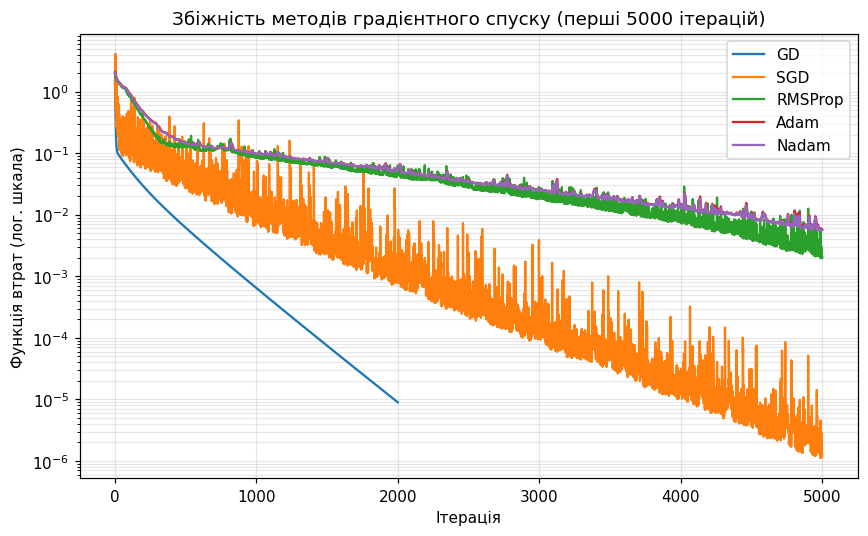

In [21]:
plt.figure(figsize=(8, 5))
for name, cfg in methods_config.items():
    fn = cfg["fn"]
    n_iter_plot = min(cfg["n_iter"], 5000)
    theta, hist = fn(X_poly, y, lr=cfg["lr"], n_iter=n_iter_plot)
    plt.plot(np.arange(1, n_iter_plot + 1), hist, label=name)

plt.yscale("log")
plt.xlabel("Ітерація")
plt.ylabel("Функція втрат (лог. шкала)")
plt.title("Збіжність методів градієнтного спуску (перші 5000 ітерацій)")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

### Висновки

**Точність.** Усі п'ять методів успішно знаходять коефіцієнти полінома, близькі до справжніх $\theta_{true}=[0,3,-6,4,-2,5]$. При підібраній кількості ітерацій найточніший результат дають Adam ($\|\theta-\theta_{true}\|^2/n \approx 5.8\times10^{-8}$) та Nadam ($\approx 5.8\times10^{-8}$–$2.5\times10^{-7}$), далі йдуть SGD ($\approx 1.6\times10^{-4}$), RMSProp ($\approx 1.3\times10^{-4}$) і GD ($\approx 1.4\times10^{-3}$ при обраному порозі збіжності).

**Швидкість (`%timeit`, для підібраної кількості ітерацій кожного методу).**

| Метод | n_iter | Час виконання |
|---|---|---|
| GD | 2 000 | ≈ 20 мс |
| SGD | 5 000 | ≈ 52 мс |
| Adam | 10 000 | ≈ 189 мс |
| Nadam | 10 000 | ≈ 218 мс |
| RMSProp | 50 000 | ≈ 735 мс |

**Кількість ітерацій, необхідна для збіжності (поріг функції втрат $10^{-4}$).** GD виявився найекономнішим — йому достатньо лише ~2 000 ітерацій, оскільки на кожному кроці він використовує *точний* градієнт, усереднений по всій (невеликій, 100 прикладів) вибірці. SGD потребує вже ~5 000 ітерацій — його градієнт по одному прикладу "шумний", тому рух до мінімуму менш прямолінійний (це добре видно на графіку збіжності: крива SGD осцилює, хоч і йде вниз швидше за адаптивні методи). Adam і Nadam при використанному темпі навчання виходять на дуже низьку похибку вже після ~10 000 ітерацій, а от RMSProp без згладжування першого моменту (momentum) сходиться значно повільніше — знадобилося 50 000 ітерацій.

**Загальний висновок про обчислювальну ефективність.** Для цієї задачі (100 прикладів, 6 ознак) найефективнішим виявився класичний пакетний градієнтний спуск (GD): він дає точний градієнт на кожному кроці, тому потребує найменшої кількості ітерацій і найменшого часу виконання. Стохастичні та адаптивні методи (SGD, RMSProp, Adam, Nadam) обчислюють градієнт по одному прикладу, що робить кожен окремий крок значно дешевшим за прохід по всій вибірці — проте на такому малому наборі даних ця перевага не реалізується, бо накладні витрати Python-циклу на ітерацію переважають виграш від менших обчислень, а для збіжності потрібно значно більше кроків. Adam і Nadam завдяки поєднанню моменту (згладжування напрямку) та адаптивного масштабування кроку є найбільш "збалансованими" серед стохастичних методів — вони дають набагато вищу точність за прийнятний час порівняно з "голим" RMSProp. Очікується, що на великих наборах даних (тисячі-мільйони прикладів), де обчислення точного градієнта по всій вибірці на кожній ітерації GD стає надто дорогим, переваги стохастичних і особливо адаптивних методів (Adam/Nadam) проявляться значно яскравіше — саме тому вони є стандартом де-факто для навчання великих моделей.